In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

### Robot Sample Locations

In [2]:
# Build robot data table 
ranges = pd.read_csv('range.csv')
locations = pd.read_csv('robot_locations.csv')

robots = (
    locations.merge(ranges, on='index', how='inner')
    .rename(columns={'index': 'robot_id'})
    [['robot_id', 'longitude', 'latitude', 'range']]
    .sort_values('robot_id')
    .reset_index(drop=True)
)

#robots.to_csv('robot_table.csv', index=False)
robots.head()

,robot_id,longitude,latitude,range
0,0,-120.240815,-79.238374,127.868274
1,1,-134.537839,-83.426214,87.246488
2,2,-105.282215,-84.681705,64.393799
3,3,-105.453243,-77.964007,100.815352
4,4,-168.816260,-86.934888,36.021544


Number of robots: 1072
Longitude range: -179.589 to 179.986
Latitude range: -89.992 to -63.988
Robot range: 10.743 to 173.899


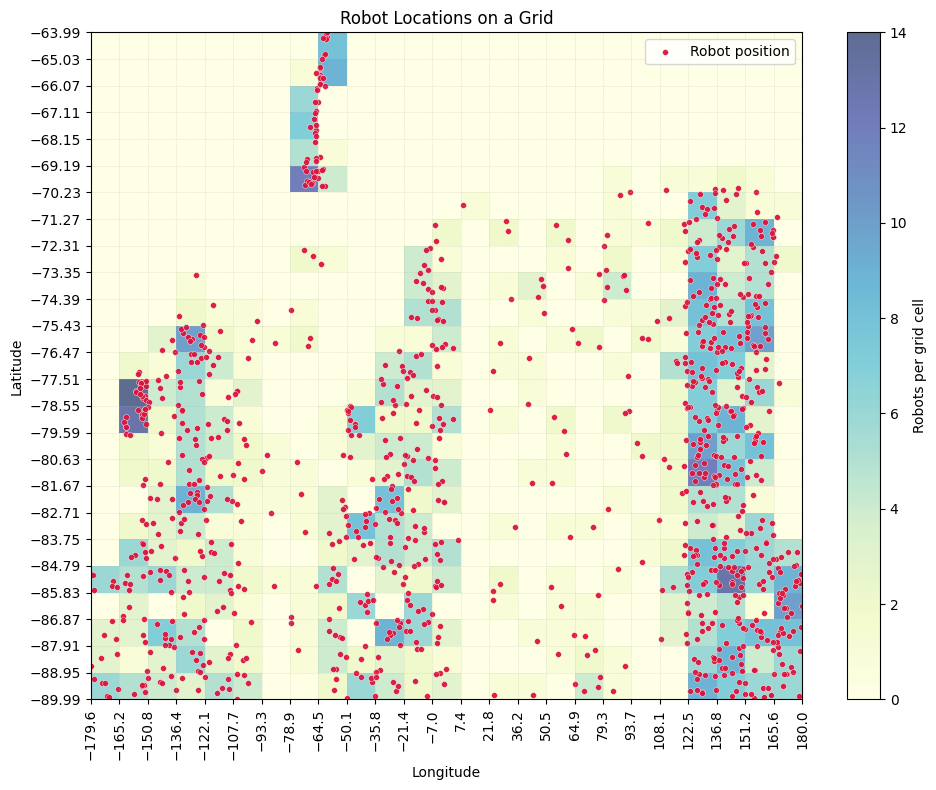

In [3]:
print(f'Number of robots: {len(robots)}')
print(f'Longitude range: {robots.longitude.min():.3f} to {robots.longitude.max():.3f}')
print(f'Latitude range: {robots.latitude.min():.3f} to {robots.latitude.max():.3f}')
print(f'Robot range: {robots["range"].min():.3f} to {robots["range"].max():.3f}')

grid_size = 25
lon_edges = np.linspace(robots['longitude'].min(), robots['longitude'].max(), grid_size + 1)
lat_edges = np.linspace(robots['latitude'].min(), robots['latitude'].max(), grid_size + 1)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.hist2d(
    robots['longitude'],
    robots['latitude'],
    bins=[lon_edges, lat_edges],
    cmap='YlGnBu',
    alpha=0.65
)
ax.scatter(
    robots['longitude'],
    robots['latitude'],
    s=18,
    c='crimson',
    edgecolors='white',
    linewidths=0.3,
    marker='o',
    alpha=0.95,
    label='Robot position'
)
plt.colorbar(heatmap[3], ax=ax, label='Robots per grid cell')
ax.set_title('Robot Locations on a Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xticks(lon_edges)
ax.set_yticks(lat_edges)
ax.tick_params(axis='x', labelrotation=90)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [4]:
# Random sample of robots

robots_subset = robots.sample(n=100, random_state=1).reset_index(drop=True).copy()

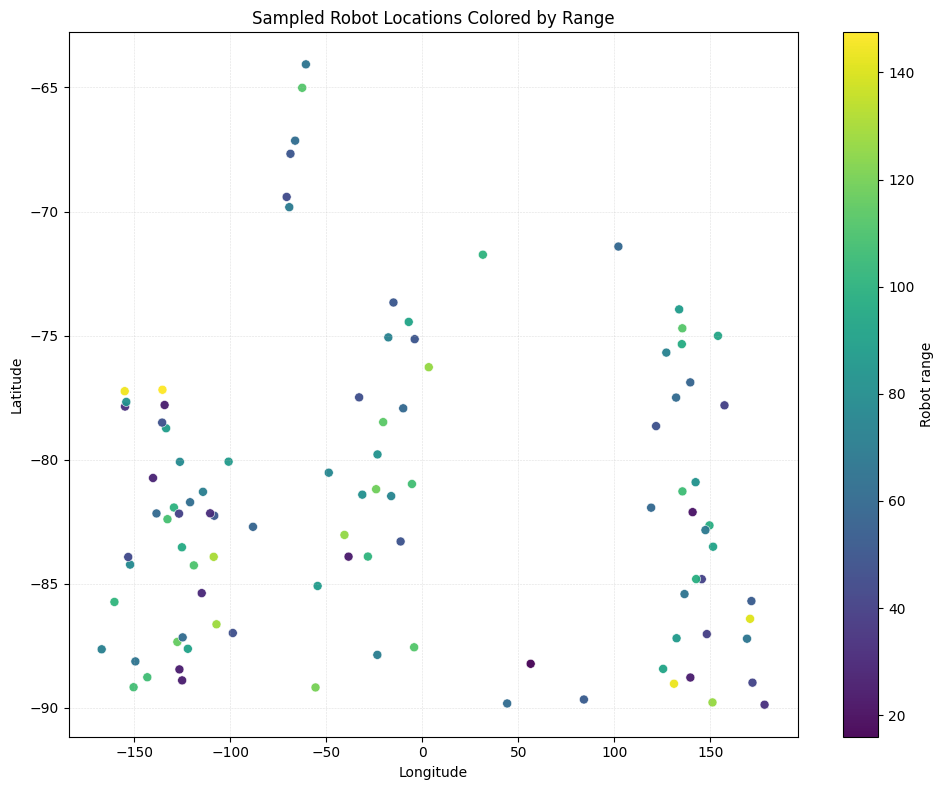

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    robots_subset['longitude'],
    robots_subset['latitude'],
    c=robots_subset['range'],
    cmap='viridis',
    s=42,
    edgecolors='white',
    linewidths=0.4,
    alpha=0.95
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Robot range')
ax.set_title('Sampled Robot Locations Colored by Range')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
plt.tight_layout()
plt.show()


### Model

### Decision Variables

- $y_j \in \{0,1\}$: equals 1 if station $j$ is built  
- $z_j \in \mathbb{Z}_+$: number of chargers at station $j$  
- $x_{ij} \in \{0,1\}$: equals 1 if robot $i$ is assigned to station $j$  

- $s_j^x \in \mathbb{R}$: x-coordinate (longitude) of station $j$  
- $s_j^y \in \mathbb{R}$: y-coordinate (latitude) of station $j$  

- $d_{ij} \geq 0$: distance from robot $i$ to station $j$  

- $u_{ij} \in \{0,1\}$: equals 1 if robot $i$ requires human transport to station $j$  


### Parameters

- $I$: set of robots  
- $J$: set of potential station indices  

- $(a_i, b_i)$: coordinates of robot $i$  
- $r_i$: range of robot $i$  

- $m$: maximum number of chargers per station  
- $q$: maximum number of robots per charger  

- $c_b$: build cost per station  
- $c_m$: maintenance cost per charger  
- $c_c$: charging cost per km  
- $c_h$: transport cost  

- $r_{\max}$: full recharge level  
- $T = 365$: planning horizon  

- $M$: sufficiently large constant  



### Constraints
The same constraints as the other model, olus additional ones as candidate locations are fixed and therefore we do not have a finite set of robot-candidate distances and thus also not a set list of whether a canddiates location is reachable for a robot. 


#### Assignment

Each robot must be assigned to exactly one station:

$$
\sum_{j \in J} x_{ij} = 1 \quad \forall i \in I
$$



#### Station Opening

Assignment is only possible if the station is built:

$$
x_{ij} \leq y_j \quad \forall i \in I,\; j \in J
$$



#### Capacity

Each charger serves at most $q$ robots:

$$
\sum_{i \in I} x_{ij} \leq q \cdot z_j \quad \forall j \in J
$$



#### Charger Limit

Each station can have at most $m$ chargers:

$$
z_j \leq m \cdot y_j \quad \forall j \in J
$$



#### Distance Definition

Distance must satisfy the Euclidean relation:

$$
(a_i - s_j^x)^2 + (b_i - s_j^y)^2 \leq d_{ij}^2 
\quad \forall i \in I,\; j \in J
$$



#### Transport Trigger

If a robot is assigned beyond its range, transport must be activated:

$$
d_{ij} - r_i \leq M \big(u_{ij} + 1 - x_{ij} \big)
\quad \forall i \in I,\; j \in J
$$



#### Transport Consistency

Transport only occurs if the robot is assigned:

$$
u_{ij} \leq x_{ij} \quad \forall i \in I,\; j \in J
$$

Prevents case where robot is not assigned to station j but model still says it needs transport to station j.



### Objective Function

Minimize total annual cost:

$$
\min \sum_{j \in J} \left( c_b y_j + c_m z_j \right)
$$

$$
+ \; T \sum_{i \in I} \sum_{j \in J}
c_c \Big[
(r_{\max} - r_i + d_{ij})(x_{ij} - u_{ij})
+ (r_{\max} - r_i)u_{ij}
\Big]
$$

$$
+ \; T \sum_{i \in I} \sum_{j \in J} c_h u_{ij}
$$



### Interpretation of Cost

- If robot $i$ reaches station $j$:
  
$$
u_{ij} = 0 \quad \Rightarrow \quad 
\text{charge} = r_{\max} - r_i + d_{ij}
$$

- If robot $i$ cannot reach station $j$:

$$
u_{ij} = 1 \quad \Rightarrow \quad 
\text{charge} = r_{\max} - r_i
$$

and incurs additional transport cost:

$$
c_h
$$

we assume that if robot doesnt have range to reach charging location, it will be picked up from its current position. 

### Summary

Model uses J = list(range(1, len(I) + 1)), so the continuous MINLP creates one potential station slot per robot. That gives O(|I|^2) binary assignment, distance, and transport variables, plus nonconvex distance constraints for every (i,j) pair. This is the main computational bottleneck in 1a_b; for anything beyond very small samples it is not efficient. Cap |J| to a much smaller value or solve multiple runs with small fixed k instead.

This model determines:

- Where to locate charging stations  
- Which stations to build  
- How many chargers to install  
- How to assign robots to stations  

while minimizing total annual cost subject to assignment, capacity, and reachability constraints.

In [6]:
# Model parameters from the assignment.
planning_days = 365 # run model for a year to account for annual costs
m = 8
q = 2
c_b = 5000
c_h = 1000
c_m = 500
c_c = 0.42
lambda_ = 0.012
r_min = 10
r_max = 175

I = robots_subset["robot_id"].astype(int).tolist() # list of robot IDs
J = list(range(1, len(I) + 1)) # list of potential locations (1 per robot) (worst case each robot has its own location)

# Create mapping dictionaries for the model parameters
lon_dict = robots_subset.set_index("robot_id")["longitude"].to_dict() # Robot ID -> Longitude
lat_dict = robots_subset.set_index("robot_id")["latitude"].to_dict() # Robot ID -> Latitude
range_dict = robots_subset.set_index("robot_id")["range"].to_dict() # Robot ID -> Range

# Find minimum and maximum longitude and latitude for sample of robots
x_min = robots_subset["longitude"].min()
x_max = robots_subset["longitude"].max()
y_min = robots_subset["latitude"].min()
y_max = robots_subset["latitude"].max()

# Create diagonal distance M for the model (worst case distance between any two points in the area) (for big-M constraints)
M_dist = float(np.sqrt((x_max - x_min) ** 2 + (y_max - y_min) ** 2))

print("Robots:", len(I))
print("Station slots:", len(J))
print("M_dist:", M_dist)

Robots: 100
Station slots: 100
M_dist: 346.3112775543908


In [7]:
# Create model
model = pyo.ConcreteModel()

# Sets
model.I = pyo.Set(initialize=I)
model.J = pyo.Set(initialize=J)

# Parameters
model.lon = pyo.Param(model.I, initialize=lon_dict) # Robot ID -> Longitude
model.lat = pyo.Param(model.I, initialize=lat_dict) # Robot ID -> Latitude
model.r = pyo.Param(model.I, initialize=range_dict) # Robot ID -> Range    

# Decision variables

model.y = pyo.Var(model.J, domain=pyo.Binary) # y[j] = 1 if station is built at location j, 0 otherwise
model.z = pyo.Var(model.J, domain=pyo.NonNegativeIntegers) # z[j] = number of chargers built at station at location j
model.x = pyo.Var(model.I, model.J, domain=pyo.Binary) # x[i,j] = 1 if robot i is assigned to station at location j, 0 otherwise

# (bounds restrict location to improve solver performance)
model.sx = pyo.Var(model.J, bounds=(x_min, x_max)) # sx[j] = longitude of station at location j
model.sy = pyo.Var(model.J, bounds=(y_min, y_max)) # sy[j] = latitude of station at location j
model.d = pyo.Var(model.I, model.J, domain=pyo.NonNegativeReals) # d[i,j] = distance from robot i to station at location j (for big-M constraints)
model.u = pyo.Var(model.I, model.J, domain=pyo.Binary) # u[i,j] = 1 if robot i assigned to station j requires human transport


In [8]:
# Every robot must be assigned to exactly one station.
def assign_once_rule(model, i):
    return sum(model.x[i, j] for j in model.J) == 1
model.assign_once = pyo.Constraint(model.I, rule=assign_once_rule)

# A robot can only be assigned to a station if that station is built.
def open_link_rule(model, i, j):
    return model.x[i, j] <= model.y[j]
model.open_link = pyo.Constraint(model.I, model.J, rule=open_link_rule)

# Number of robots assigned to station j cannot exceed the number of chargers built at station j times the charger capacity q.
def charger_capacity_rule(model, j):
    return sum(model.x[i, j] for i in model.I) <= q * model.z[j]
model.charger_capacity = pyo.Constraint(model.J, rule=charger_capacity_rule)

# Number of chargers built at station j cannot exceed the maximum number of chargers m times whether the station is built or not.
def charger_limit_rule(model, j):
    return model.z[j] <= m * model.y[j]
model.charger_limit = pyo.Constraint(model.J, rule=charger_limit_rule)

# Distance from robot i to station j (d[i,j]) must be at least the Euclidean distance between robot i and station j 
def distance_rule(model, i, j):
    return (model.lon[i] - model.sx[j])**2 + (model.lat[i] - model.sy[j])**2 <= model.d[i, j]**2
model.distance_def = pyo.Constraint(model.I, model.J, rule=distance_rule)

# If robot i is assigned to station j and the distance is greater than the robot's range, then u[i,j] must equal 1
def transport_trigger_rule(model, i, j):
    return model.d[i, j] - model.r[i] <= M_dist * (model.u[i, j] + 1 - model.x[i, j])
model.transport_trigger = pyo.Constraint(model.I, model.J, rule=transport_trigger_rule)

# Human transport can only happen for the station that the robot is assigned to, so if x[i,j] = 0 then u[i,j] must also equal 0
def transport_assign_link_rule(model, i, j):
    return model.u[i, j] <= model.x[i, j]
model.transport_assign_link = pyo.Constraint(model.I, model.J, rule=transport_assign_link_rule)


In [9]:
# Minimise annualised costs: 

def objective_rule(model):

    # cost of building stations (c_b * y_j) and chargers (c_m * z_j) (paid one time per year)
    fixed_cost = sum(c_b * model.y[j] + c_m * model.z[j] for j in model.J) 


    # cost of charging robots. If needs rescue then cost is c_c * (r_max - r[i]), otherwise cost is c_c * (r_max - (r_i - d[i,j]) * x[i,j]) 
    # (paid every time a robot is charged, so annualised by multiplying by planning_days)
    charging_cost = planning_days * sum(
        c_c * (
            (r_max - model.r[i] + model.d[i, j]) * (model.x[i, j] - model.u[i, j])
            + (r_max - model.r[i]) * model.u[i, j]
        )
        for i in model.I for j in model.J
    )




    # cost of human transport (c_h * u[i,j]) (paid every time a robot is transported, so annualised by multiplying by planning_days)
    transport_cost = planning_days * sum(c_h * model.u[i, j] for i in model.I for j in model.J)

    return fixed_cost + charging_cost + transport_cost

model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)


In [10]:
solver = pyo.SolverFactory("gurobi")

solver.options["TimeLimit"] = 300
#solver.options["MIPGap"] = 0.01
solver.options["NonConvex"] = 2
#solver.options["NoRelHeurTime"] = 30

results = solver.solve(model, tee=True)

print("Status:", results.solver.status)
print("Termination:", results.solver.termination_condition)
print("Objective:", pyo.value(model.obj))


Read LP format model from file C:\Users\asher\AppData\Local\Temp\tmpc8n5xwb4.pyomo.lp
Reading time = 0.42 seconds
x1: 30300 rows, 30400 columns, 90300 nonzeros
Set parameter TimeLimit to value 300
Set parameter NonConvex to value 2
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300
NonConvex  2

Optimize a model with 30300 rows, 30400 columns and 90300 nonzeros (Min)
Model fingerprint: 0x6818b254
Model has 20200 linear objective coefficients
Model has 20000 quadratic objective terms
Model has 10000 quadratic constraints
Variable types: 10200 continuous, 20200 integer (20100 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+02]
  QMatrix range    [1e+00, 1e+00]
  QLMatrix range   [7e+00, 4e+02]
  Objective range  [5e+02, 4e+05]
  QObjective ran

### Results

In [11]:
built_stations = []
for j in model.J:
    if pyo.value(model.y[j]) > 0.5:
        built_stations.append({
            "station_id": j,
            "longitude": pyo.value(model.sx[j]),
            "latitude": pyo.value(model.sy[j]),
            "chargers": int(round(pyo.value(model.z[j])))
        })

built_stations_df = pd.DataFrame(built_stations)
display(built_stations_df)

assignments = []
for i in model.I:
    for j in model.J:
        if pyo.value(model.x[i, j]) > 0.5:
            assignments.append({
                "robot_id": i,
                "station_id": j,
                "distance": pyo.value(model.d[i, j]),
                "range": pyo.value(model.r[i]),
                "needs_transport": int(round(pyo.value(model.u[i, j])))
            })

assignments_df = pd.DataFrame(assignments)
display(assignments_df)

,station_id,longitude,latitude,chargers
0,25,0.0,-64.068061,1
1,85,0.0,-64.068061,2
2,87,0.0,-64.068061,2
3,90,0.0,-64.068061,7
4,91,0.0,-64.068061,5
5,94,0.0,-64.068061,8
6,96,0.0,-64.068061,2
7,98,0.0,-64.068061,8
8,99,0.0,-64.068061,8
9,100,0.0,-64.068061,8


,robot_id,station_id,distance,range,needs_transport
0,120,94,109.609973,127.887414,0
1,552,98,132.865878,60.391929,1
2,90,91,110.508485,130.136422,0
3,973,91,60.677304,65.957089,0
4,667,100,147.041409,41.008548,1
...,...,...,...,...,...
95,133,90,102.211523,87.147124,1
96,719,90,217.458954,140.980940,1
97,388,90,20.868079,73.456016,0
98,255,91,29.561961,118.226220,0


In [12]:
def _as_float(value):
    try:
        if value is None:
            return None
        return float(value)
    except (TypeError, ValueError):
        return None

number_of_robots = len(model.I)
number_of_stations = int(round(sum(pyo.value(model.y[j]) for j in model.J)))
number_of_chargers = int(round(sum(pyo.value(model.z[j]) for j in model.J)))

buildings_cost = sum(
    c_b * pyo.value(model.y[j]) + c_m * pyo.value(model.z[j])
    for j in model.J
)

assignment_cost = planning_days * sum(
    c_c * (
        (r_max - pyo.value(model.r[i]) + pyo.value(model.d[i, j])) * (pyo.value(model.x[i, j]) - pyo.value(model.u[i, j]))
        + (r_max - pyo.value(model.r[i])) * pyo.value(model.u[i, j])
    )
    for i in model.I for j in model.J
)

transport_cost = planning_days * sum(
    c_h * pyo.value(model.u[i, j])
    for i in model.I for j in model.J
)

total_cost = pyo.value(model.obj)
robots_needing_transport = int(assignments_df["needs_transport"].sum()) if not assignments_df.empty else 0

lower_bound = _as_float(getattr(results.problem, "lower_bound", None))
upper_bound = _as_float(getattr(results.problem, "upper_bound", None))
mip_gap = _as_float(getattr(results.solver, "mip_gap", None))

if mip_gap is None:
    mip_gap = _as_float(getattr(results.solver, "gap", None))

if mip_gap is None and lower_bound is not None and upper_bound is not None:
    mip_gap = abs(upper_bound - lower_bound) / max(abs(upper_bound), 1e-9)

results_summary = pd.DataFrame([
    {
        "Number of robots": number_of_robots,
        "Number of stations": number_of_stations,
        "Number of chargers": number_of_chargers,
        "Total cost": total_cost,
        "Assignment cost": assignment_cost,
        "Buildings cost": buildings_cost,
        "Transport cost": transport_cost,
        "Robots needing transport": robots_needing_transport,
        "MIP gap": mip_gap,
        "MIP gap (%)": None if mip_gap is None else 100 * mip_gap,
    }
])

results_summary_display = pd.DataFrame([
    {"Metric": "Number of robots", "Value": f"{number_of_robots:,.0f}"},
    {"Metric": "Number of stations", "Value": f"{number_of_stations:,.0f}"},
    {"Metric": "Number of chargers", "Value": f"{number_of_chargers:,.0f}"},
    {"Metric": "Total cost", "Value": f"{total_cost:,.2f}"},
    {"Metric": "Assignment cost", "Value": f"{assignment_cost:,.2f}"},
    {"Metric": "Buildings cost", "Value": f"{buildings_cost:,.2f}"},
    {"Metric": "Transport cost", "Value": f"{transport_cost:,.2f}"},
    {"Metric": "Robots needing transport", "Value": f"{robots_needing_transport:,.0f}"},
    {"Metric": "MIP gap", "Value": "N/A" if mip_gap is None else f"{mip_gap:.6f}"},
    {"Metric": "MIP gap (%)", "Value": "N/A" if mip_gap is None else f"{100 * mip_gap:.4f}%"},
])

display(results_summary_display)


,Metric,Value
0,Number of robots,100
1,Number of stations,10
2,Number of chargers,51
3,Total cost,"27,715,128.36"
4,Assignment cost,"1,724,628.36"
5,Buildings cost,"75,500.00"
6,Transport cost,"25,915,000.00"
7,Robots needing transport,71
8,MIP gap,0.943017
9,MIP gap (%),94.3017%


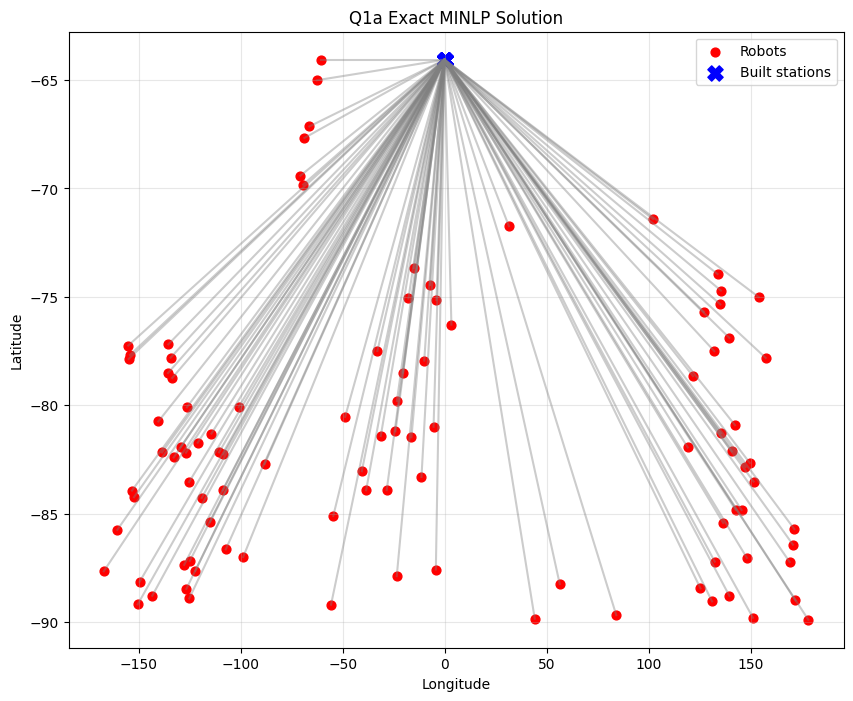

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    robots_subset["longitude"],
    robots_subset["latitude"],
    c="red",
    s=40,
    label="Robots"
)

if not built_stations_df.empty:
    ax.scatter(
        built_stations_df["longitude"],
        built_stations_df["latitude"],
        c="blue",
        s=120,
        marker="X",
        label="Built stations"
    )

    for _, row in assignments_df.iterrows():
        station = built_stations_df[built_stations_df["station_id"] == row["station_id"]].iloc[0]
        robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
        ax.plot(
            [robot["longitude"], station["longitude"]],
            [robot["latitude"], station["latitude"]],
            color="gray",
            alpha=0.4
        )

ax.set_title("Q1a Exact MINLP Solution")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
#fig.savefig("Graphs/assignments_1a_b_100.png", dpi=300, bbox_inches="tight")
plt.show()